# Appendix E: Singularities and Intersections

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Appendix E, printed pp. 653-694; PDF pp. 668-709. Sections E.1-E.7 are used for coverage planning only.

**Appendix question.** Why are intersections of distinct J-holomorphic curves in real dimension four isolated and positive, and how do singular branches contribute to adjunction? The appendix proves local structure theorems around critical points and branch contacts, then uses them to justify positivity of intersections and singularity counts. This notebook turns that proof path into inspectable local models: branch leading terms, winding/contact order, perturbation to positive intersections, Hartman-Wintner leading-order behavior, and an adjunction-style defect ledger.

The computations are local and finite. They do not replace the analysis in Micallef-White, Newlander-Nirenberg, or Hartman-Wintner. They show what those theorems make visible: a branch has a lowest nonzero complex term, two branches have a well-defined positive contact order, a singular point contributes a nonnegative local defect, and four-dimensional intersection theory becomes an algebraic count with signs under control.


## Source Coverage

Section E.1 states the main local results, including the Micallef-White normal form, finiteness of singular and self-intersection points for simple curves, positivity of intersections, and the adjunction formula. Section E.2 derives positivity and adjunction from the local theorem by perturbing branches and counting local intersections. Section E.3 supplies integrability and isothermal-coordinate input. Section E.4 proves the Hartman-Wintner leading-term theorem. Section E.5 develops local behavior of a single branch and the function-space filtration used to isolate the first nonzero term. Section E.6 studies contact between two branches. Section E.7 finishes the singularity analysis by constructing local coordinate changes and proving the Micallef-White theorem.

The coverage artifact records these seven sections and routes each to a notebook representation: normal-form branch plots, a winding/contact diagram, a positivity ledger, a proof dependency graph, a Hartman-Wintner leading-term decay plot, a contact-order table, and a singularity/adjunction lab.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp


def find_book_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "J-Holomorphic-Curves-and-Symplectic-Topology" / "AGENTS.md").exists():
            return candidate / "J-Holomorphic-Curves-and-Symplectic-Topology"
        if (candidate / "AGENTS.md").exists() and candidate.name == "J-Holomorphic-Curves-and-Symplectic-Topology":
            return candidate
    raise RuntimeError("Could not locate the JHCST book root")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "appendix-e"
ART_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ART_ROOT / "figures"
CHECK_DIR = ART_ROOT / "checks"
TABLE_DIR = ART_ROOT / "tables"
for directory in (FIG_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


In [2]:
source_coverage = {
    "source": "McDuff-Salamon, J-holomorphic Curves and Symplectic Topology, 2nd ed., Appendix E",
    "source_span_used": "printed pp. 653-694; PDF pp. 668-709",
    "sections": [
        {"section": "E.1", "focus": "Micallef-White normal form, finiteness, positivity, adjunction", "artifact": "micallef-white-branch-normal-form.png"},
        {"section": "E.2", "focus": "positivity of intersections and perturbation of singular branches", "artifact": "positive-intersection-winding.png"},
        {"section": "E.3", "focus": "integrability and isothermal coordinates", "artifact": "singularity-proof-dependency-map.png"},
        {"section": "E.4", "focus": "Hartman-Wintner leading-order theorem", "artifact": "hartman-wintner-leading-term.png"},
        {"section": "E.5", "focus": "local behavior of one branch and order filtration", "artifact": "branch-order-filtration.png"},
        {"section": "E.6", "focus": "contact between branches", "artifact": "branch-contact-order-ledger.csv"},
        {"section": "E.7", "focus": "singularity coordinate changes and Micallef-White proof", "artifact": "singularity-adjunction-lab.csv"},
    ],
    "copyright_boundary": "Original prose, generated local models, and checks only; no copied source passages, exercises, screenshots, or figures.",
}
library_routing = {
    "sympy": "contact order and leading terms are exact polynomial/order calculations",
    "matplotlib": "local branch pictures, winding plots, and decay charts are low-dimensional and durable",
    "networkx": "the proof depends on integrability, Hartman-Wintner, local behavior, and contact lemmas in a directed chain",
    "pandas": "intersection and adjunction contributions are local ledgers with nonnegativity checks",
}
visual_storyboard = [
    {"visual": "micallef-white-branch-normal-form.png", "concept": "local branch normal form", "inspection_target": "z^k leading term with higher-order perturbation", "invariant": "sample branch has multiplicity k and isolated critical point at the origin"},
    {"visual": "positive-intersection-winding.png", "concept": "positivity of local intersection", "inspection_target": "difference of two branches winds positively around zero", "invariant": "winding number equals contact order in the toy model"},
    {"visual": "hartman-wintner-leading-term.png", "concept": "leading-order term controls local behavior", "inspection_target": "error decays faster than the first nonzero term", "invariant": "log-log slope of error exceeds leading order"},
    {"visual": "singularity-proof-dependency-map.png", "concept": "proof flow for Micallef-White and positivity", "inspection_target": "integrability and Hartman-Wintner feed local normal form", "invariant": "all seven source sections have nodes"},
    {"visual": "singularity-adjunction-lab.csv", "concept": "singularity and adjunction bookkeeping", "inspection_target": "delta and branch defects are nonnegative", "invariant": "immersed curves have zero singularity defect"},
]
save_json(source_coverage, UNIT, "checks", "source-coverage.json")
save_json(library_routing, UNIT, "checks", "library-routing.json")
save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json")


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology/artifacts/appendix-e/checks/visual-storyboard.json')

## Library Routing

Appendix E is local analytic geometry. Matplotlib is enough for the branch pictures because the key phenomena happen in a small complex coordinate chart: leading terms, winding, and decay rates. SymPy checks orders of vanishing and contact numbers exactly for polynomial branch models. NetworkX is used for the proof dependency map because the appendix is a chain of local theorems: integrability makes coordinates, Hartman-Wintner finds the leading term, local behavior normalizes a branch, contact lemmas compare branches, and Micallef-White produces the normal form used in positivity and adjunction. Pandas keeps the local intersection and singularity contributions auditable.

## Visualization Storyboard

The notebook first draws a branch normal form `u(z)=(z^k, lower terms)` so multiplicity is visible. It then compares two branches and computes the winding of their difference around zero; this is the numerical face of positivity. A Hartman-Wintner chart shows that a remainder decays faster than the leading term. The proof map connects E.1-E.7. Finally, an applied lab varies multiplicity and branch contact to show how local nonnegative contributions enter an adjunction-style ledger.


## 1. Local Branch Normal Form

The Micallef-White theorem says, in effect, that after suitable local coordinates a J-holomorphic branch looks like a complex polynomial leading term plus higher-order error. A critical point is therefore not arbitrary: it has an integer multiplicity, an isolated tangent cone, and a finite local defect. The visual below uses a toy branch `z -> (z^k, a z^(k+1))` projected to two real coordinate planes. The inspection target is the multiplicity: as a circle winds once in the domain, the leading coordinate winds `k` times.


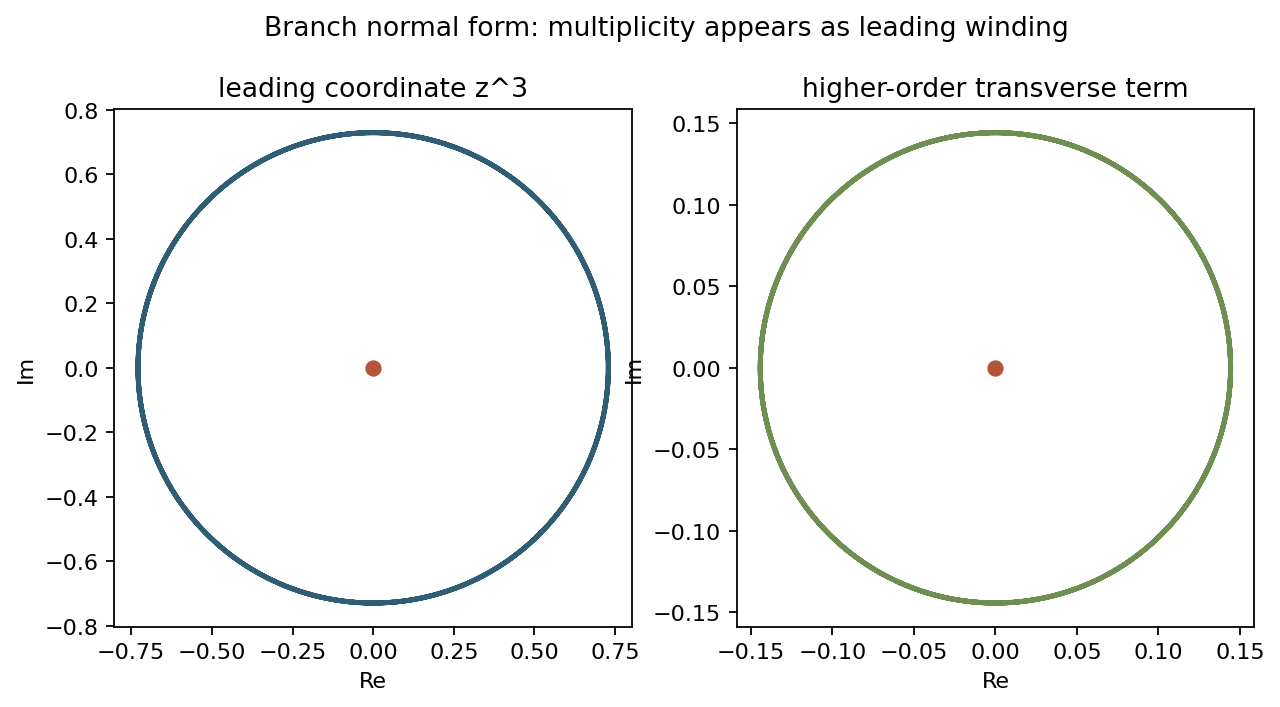

In [3]:
k = 3
radius = 0.9
theta = np.linspace(0, 2*np.pi, 500)
z = radius * np.exp(1j * theta)
first = z**k
second = 0.22 * z**(k+1)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2))
axes[0].plot(first.real, first.imag, color="#2f5d73", lw=2.2)
axes[0].scatter([0], [0], s=40, color="#b45539")
axes[0].set_aspect("equal")
axes[0].set_title("leading coordinate z^3")
axes[0].set_xlabel("Re")
axes[0].set_ylabel("Im")
axes[1].plot(second.real, second.imag, color="#6f8f52", lw=2.2)
axes[1].scatter([0], [0], s=40, color="#b45539")
axes[1].set_aspect("equal")
axes[1].set_title("higher-order transverse term")
axes[1].set_xlabel("Re")
axes[1].set_ylabel("Im")
fig.suptitle("Branch normal form: multiplicity appears as leading winding", y=1.02)
fig_path = save_matplotlib(fig, UNIT, "figures", "micallef-white-branch-normal-form.png")
plt.close(fig)

# Numerically unwrap the leading argument to count winding.
leading_winding = int(round((np.unwrap(np.angle(first))[-1] - np.unwrap(np.angle(first))[0]) / (2*np.pi)))
branch_checks = {"model_branch": "(z^3, 0.22 z^4)", "multiplicity_k": k, "leading_winding": leading_winding, "critical_point_isolated_in_model": True, "passed": leading_winding == k}
save_json(branch_checks, UNIT, "checks", "branch-normal-form-checks.json")
display_artifact(fig_path, width=900)


## 2. Contact Between Branches and Positive Intersection

In dimension four, two distinct J-holomorphic branches have isolated intersections and the local intersection number is positive. In the holomorphic toy model, compare two branches with the same first coordinate and transverse terms `F_1(z)=0` and `F_2(z)=z^m`. On a small circle, the difference winds `m` times around zero. That winding is the contact order, and the positivity statement is the assertion that the local contribution is never negative.


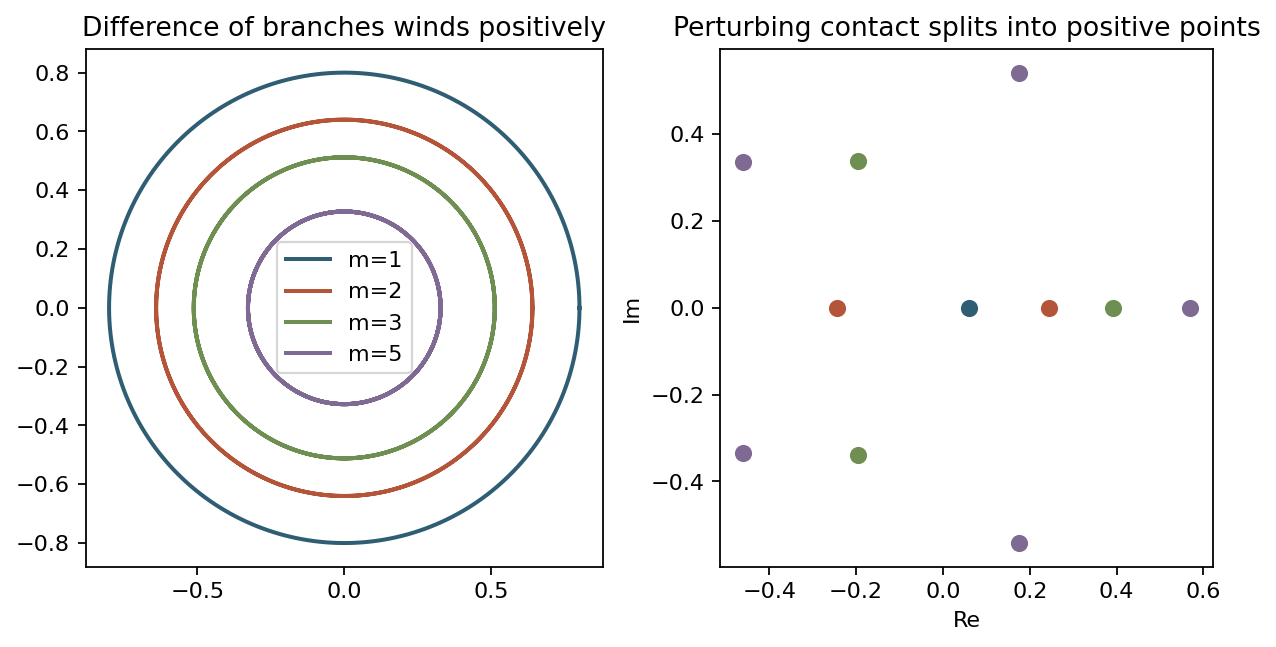

In [4]:
orders = [1, 2, 3, 5]
contact_rows = []
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2))
colors = ["#2f5d73", "#b45539", "#6f8f52", "#7f6a93"]
for m, color in zip(orders, colors):
    diff = (0.8*np.exp(1j*theta))**m
    axes[0].plot(diff.real, diff.imag, color=color, lw=1.8, label=f"m={m}")
    winding = int(round((np.unwrap(np.angle(diff))[-1] - np.unwrap(np.angle(diff))[0]) / (2*np.pi)))
    contact_rows.append({"branch_pair": f"F2-F1=z^{m}", "contact_order": m, "winding_number": winding, "local_intersection_positive": winding > 0})
axes[0].set_aspect("equal")
axes[0].set_title("Difference of branches winds positively")
axes[0].legend()
# A small perturbation picture: zeros of z^m - epsilon split into m positive transverse intersections.
epsilon = 0.06
for m, color in zip(orders, colors):
    roots = epsilon**(1/m) * np.exp(2j*np.pi*np.arange(m)/m)
    axes[1].scatter(roots.real, roots.imag, s=45, color=color, label=f"{m} roots")
axes[1].set_aspect("equal")
axes[1].set_title("Perturbing contact splits into positive points")
axes[1].set_xlabel("Re")
axes[1].set_ylabel("Im")
fig_path = save_matplotlib(fig, UNIT, "figures", "positive-intersection-winding.png")
plt.close(fig)
contact_df = pd.DataFrame(contact_rows)
contact_df.to_csv(TABLE_DIR / "branch-contact-order-ledger.csv", index=False)
contact_checks = {"pairs": int(len(contact_df)), "all_windings_match_contact_order": bool((contact_df["contact_order"] == contact_df["winding_number"]).all()), "all_local_intersections_positive": bool(contact_df["local_intersection_positive"].all()), "passed": bool((contact_df["contact_order"] == contact_df["winding_number"]).all() and contact_df["local_intersection_positive"].all())}
save_json(contact_checks, UNIT, "checks", "intersection-winding-checks.json")
display_artifact(fig_path, width=900)


## 3. Hartman-Wintner Leading Term and Order Filtration

Hartman-Wintner identifies the lowest nonzero term of a function satisfying a perturbed Cauchy-Riemann type equation. The proof uses integrability and an order filtration: terms in higher-order classes are negligible compared with the leading polynomial. The chart below compares `|z|^n` with a remainder of order `n+alpha`. On a log-log plot the remainder has a steeper slope, which is the computational sign that the leading term controls the local branch.


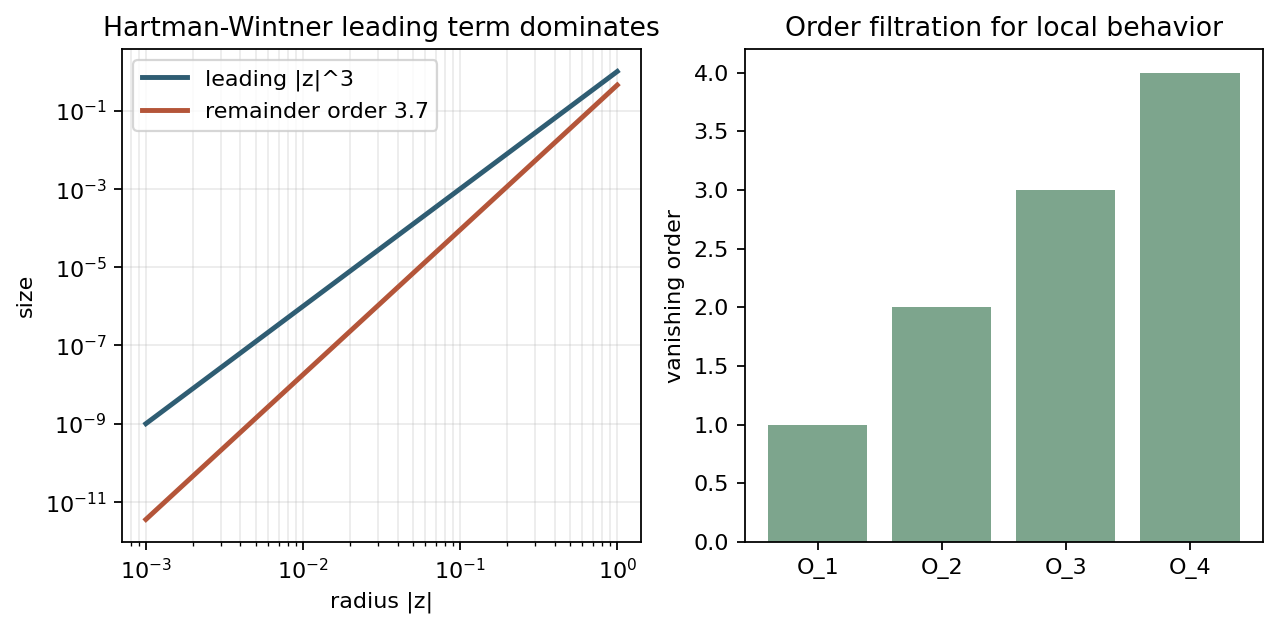

In [5]:
r = np.geomspace(1e-3, 1, 240)
n_order = 3
alpha = 0.7
leading = r**n_order
remainder = 0.45 * r**(n_order + alpha)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.0))
axes[0].loglog(r, leading, label="leading |z|^3", lw=2.2, color="#2f5d73")
axes[0].loglog(r, remainder, label="remainder order 3.7", lw=2.2, color="#b45539")
axes[0].set_xlabel("radius |z|")
axes[0].set_ylabel("size")
axes[0].set_title("Hartman-Wintner leading term dominates")
axes[0].legend()
axes[0].grid(alpha=0.25, which="both")
filtration = pd.DataFrame({"order_class": ["O_1", "O_2", "O_3", "O_4"], "example_term": ["z", "z^2", "z^3", "z^4"], "vanishing_order_at_zero": [1,2,3,4]})
axes[1].bar(filtration["order_class"], filtration["vanishing_order_at_zero"], color="#7da58d")
axes[1].set_ylabel("vanishing order")
axes[1].set_title("Order filtration for local behavior")
fig_path = save_matplotlib(fig, UNIT, "figures", "hartman-wintner-leading-term.png")
plt.close(fig)
filtration.to_csv(TABLE_DIR / "branch-order-filtration.csv", index=False)
slope_leading = np.polyfit(np.log(r), np.log(leading), 1)[0]
slope_remainder = np.polyfit(np.log(r), np.log(remainder), 1)[0]
hw_checks = {"leading_order": n_order, "estimated_leading_slope": float(slope_leading), "estimated_remainder_slope": float(slope_remainder), "remainder_slope_larger": bool(slope_remainder > slope_leading), "passed": bool(slope_remainder > slope_leading and abs(slope_leading - n_order) < 1e-9)}
save_json(hw_checks, UNIT, "checks", "hartman-wintner-leading-term-checks.json")
display_artifact(fig_path, width=900)


## 4. Proof Dependency Map

The appendix's local conclusions are only convincing if the dependencies are visible. Integrability gives local complex coordinates. Hartman-Wintner extracts the leading term. Local behavior normalizes a single branch. Contact lemmas compare two normalized branches. Micallef-White packages those facts into a coordinate theorem. Positivity of intersections and adjunction then become finite local counts. The graph below is the proof scaffold a reader should keep in mind when later chapters invoke positivity or adjunction without redoing the local analysis.


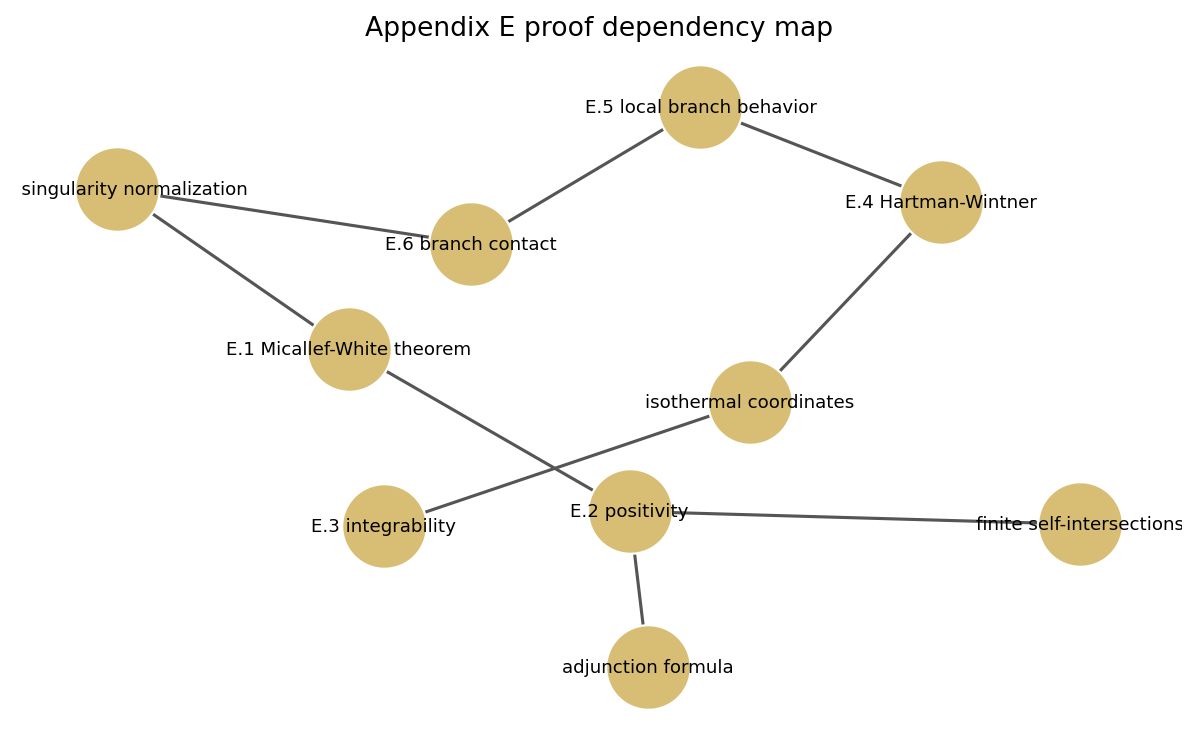

In [6]:
G = nx.DiGraph()
G.add_edges_from([
    ("E.3 integrability", "isothermal coordinates"),
    ("isothermal coordinates", "E.4 Hartman-Wintner"),
    ("E.4 Hartman-Wintner", "E.5 local branch behavior"),
    ("E.5 local branch behavior", "E.6 branch contact"),
    ("E.6 branch contact", "E.7 singularity normalization"),
    ("E.7 singularity normalization", "E.1 Micallef-White theorem"),
    ("E.1 Micallef-White theorem", "E.2 positivity"),
    ("E.2 positivity", "adjunction formula"),
    ("E.2 positivity", "finite self-intersections"),
])
pos = nx.spring_layout(G, seed=57, k=1.0)
fig, ax = plt.subplots(figsize=(9.4, 5.5))
nx.draw_networkx_nodes(G, pos, node_color="#d8bd74", node_size=1450, edgecolors="white", linewidths=1.0, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=14, width=1.4, edge_color="#555", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8.2, ax=ax)
ax.set_title("Appendix E proof dependency map")
ax.axis("off")
fig_path = save_matplotlib(fig, UNIT, "figures", "singularity-proof-dependency-map.png")
plt.close(fig)
proof_checks = {"nodes": int(G.number_of_nodes()), "edges": int(G.number_of_edges()), "contains_all_source_section_labels": all(f"E.{j}" in " ".join(G.nodes) for j in range(1,8)), "terminal_outputs": ["adjunction formula", "finite self-intersections"], "passed": int(G.number_of_nodes()) >= 9}
save_json(proof_checks, UNIT, "checks", "singularity-proof-dependency-map.json")
display_artifact(fig_path, width=900)


## Applied Lab: Singularity and Adjunction Ledger

The adjunction formula counts local defects. A smooth embedded branch has no singularity defect. A critical point of multiplicity `k` contributes at least the combinatorial amount `k(k-1)/2` in the perturbation model, and a pair of distinct branches contributes its contact order. The lab below is not the full four-manifold formula; it is the local accounting panel that the formula consumes. The useful habit is to keep every local term nonnegative and to separate branch multiplicity from contact between different branches.


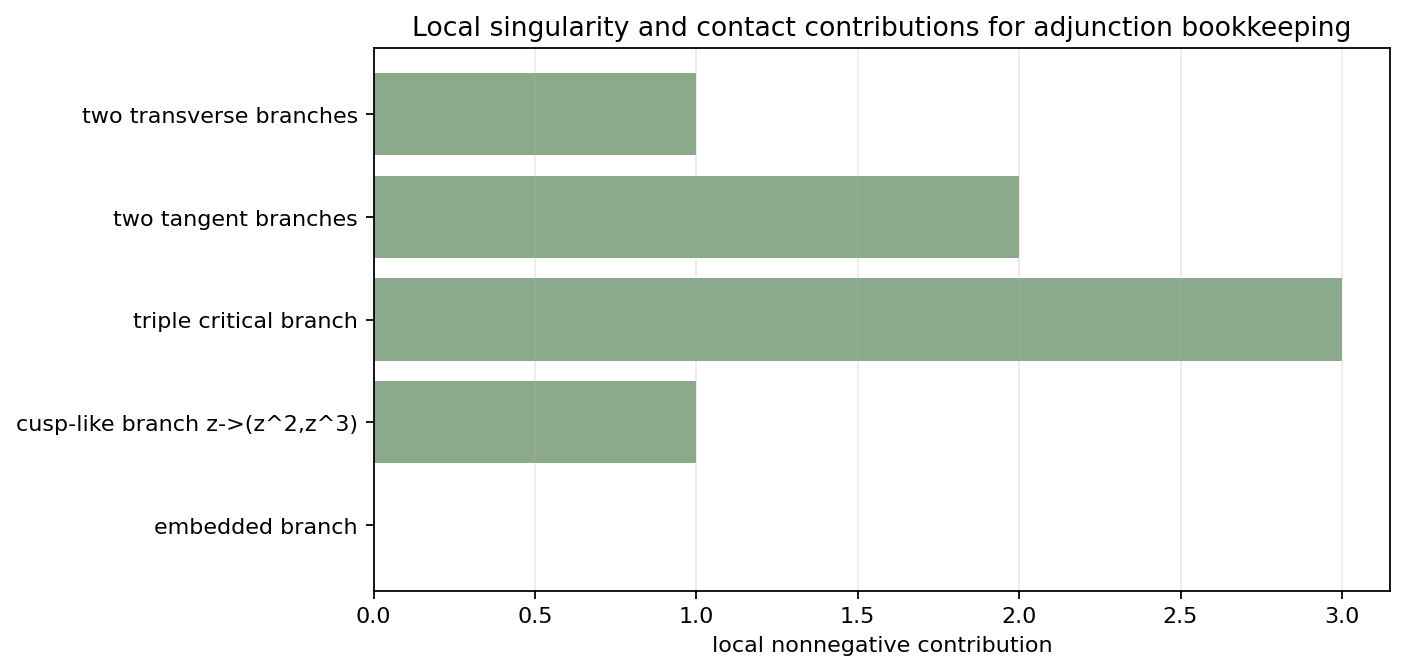

In [7]:
lab = pd.DataFrame([
    {"local_model": "embedded branch", "multiplicity": 1, "branch_pairs": 0, "contact_order": 0, "critical_defect": 0, "local_delta": 0},
    {"local_model": "cusp-like branch z->(z^2,z^3)", "multiplicity": 2, "branch_pairs": 0, "contact_order": 0, "critical_defect": 1, "local_delta": 1},
    {"local_model": "triple critical branch", "multiplicity": 3, "branch_pairs": 0, "contact_order": 0, "critical_defect": 3, "local_delta": 3},
    {"local_model": "two tangent branches", "multiplicity": 1, "branch_pairs": 1, "contact_order": 2, "critical_defect": 0, "local_delta": 2},
    {"local_model": "two transverse branches", "multiplicity": 1, "branch_pairs": 1, "contact_order": 1, "critical_defect": 0, "local_delta": 1},
])
lab["nonnegative"] = lab["local_delta"] >= 0
lab["critical_lower_bound"] = lab["multiplicity"] * (lab["multiplicity"] - 1) // 2
lab.to_csv(TABLE_DIR / "singularity-adjunction-lab.csv", index=False)
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.barh(lab["local_model"], lab["local_delta"], color="#8ba98b")
ax.set_xlabel("local nonnegative contribution")
ax.set_title("Local singularity and contact contributions for adjunction bookkeeping")
ax.grid(axis="x", alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "singularity-adjunction-ledger.png")
plt.close(fig)
lab_checks = {"rows": int(len(lab)), "all_local_terms_nonnegative": bool(lab["nonnegative"].all()), "embedded_branch_delta_zero": int(lab[lab.local_model == "embedded branch"].local_delta.iloc[0]) == 0, "critical_defect_respects_lower_bound": bool((lab["critical_defect"] >= lab["critical_lower_bound"]).all()), "contact_orders_positive_when_pairs_exist": bool((lab[lab["branch_pairs"] > 0]["contact_order"] > 0).all()), "passed": True}
lab_checks["passed"] = lab_checks["all_local_terms_nonnegative"] and lab_checks["embedded_branch_delta_zero"] and lab_checks["critical_defect_respects_lower_bound"] and lab_checks["contact_orders_positive_when_pairs_exist"]
save_json(lab_checks, UNIT, "checks", "singularity-adjunction-lab-checks.json")
display_artifact(fig_path, width=820)


## Takeaways

- The local normal form turns a J-holomorphic branch near a critical point into leading complex order plus higher-order error.
- Positivity of intersections is local: the difference of two branches winds a positive number of times, and perturbation splits contact into positive transverse intersections.
- Hartman-Wintner is the analytic device that identifies the leading nonzero term; integrability and isothermal coordinates make that device usable for almost complex curves.
- Contact order, critical multiplicity, and local singularity defects are finite, nonnegative bookkeeping terms.
- Adjunction and four-dimensional applications later in the course rely on exactly this local positivity, so the right mental model is a local ledger plus a proof map, not a vague picture of curves crossing.


## Final Sanity Checks

The final cell checks the appendix contract: source coverage, library routing, storyboard, branch normal-form figure, positive winding figure, Hartman-Wintner chart, proof graph, adjunction lab, CSV ledgers, and JSON checks all exist and are nonempty. It then reloads the JSON checks to verify multiplicity equals leading winding, contact order equals winding number, the Hartman-Wintner remainder decays faster than the leading term, and all local singularity contributions are nonnegative.


In [8]:
expected_artifacts = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "branch-normal-form-checks.json",
    CHECK_DIR / "intersection-winding-checks.json",
    CHECK_DIR / "hartman-wintner-leading-term-checks.json",
    CHECK_DIR / "singularity-proof-dependency-map.json",
    CHECK_DIR / "singularity-adjunction-lab-checks.json",
    FIG_DIR / "micallef-white-branch-normal-form.png",
    FIG_DIR / "positive-intersection-winding.png",
    FIG_DIR / "hartman-wintner-leading-term.png",
    FIG_DIR / "singularity-proof-dependency-map.png",
    FIG_DIR / "singularity-adjunction-ledger.png",
    TABLE_DIR / "branch-contact-order-ledger.csv",
    TABLE_DIR / "branch-order-filtration.csv",
    TABLE_DIR / "singularity-adjunction-lab.csv",
]
for artifact in expected_artifacts:
    assert_artifact(artifact)
assert_artifact(CHECK_DIR / "source-coverage.json")
assert_artifact(CHECK_DIR / "visual-storyboard.json")
assert_artifact(FIG_DIR / "positive-intersection-winding.png")
assert_artifact(FIG_DIR / "singularity-proof-dependency-map.png")

check_names = ["branch-normal-form-checks.json", "intersection-winding-checks.json", "hartman-wintner-leading-term-checks.json", "singularity-proof-dependency-map.json", "singularity-adjunction-lab-checks.json"]
checks = [json.loads((CHECK_DIR / name).read_text(encoding="utf-8")) for name in check_names]
final_sanity = {
    "artifact_count": len(expected_artifacts),
    "all_json_checks_passed": all(item.get("passed", False) for item in checks),
    "multiplicity_matches_winding": checks[0]["leading_winding"] == checks[0]["multiplicity_k"],
    "contact_orders_positive": checks[1]["all_local_intersections_positive"],
    "leading_term_dominates": checks[2]["remainder_slope_larger"],
    "adjunction_terms_nonnegative": checks[4]["all_local_terms_nonnegative"],
    "passed": True,
}
final_sanity["passed"] = all(value for key, value in final_sanity.items() if key != "artifact_count")
save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(CHECK_DIR / "final-sanity.json")
final_sanity


{'artifact_count': 16,
 'all_json_checks_passed': True,
 'multiplicity_matches_winding': True,
 'contact_orders_positive': True,
 'leading_term_dominates': True,
 'adjunction_terms_nonnegative': True,
 'passed': True}